# __WNBA Player Projection Analysis__

__Prepared by: Gang Huo__
<br>This notebook analyzes the performance/accuracy of WNBA player projections.

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from scipy import stats

# Suppress warnings for cleaner output
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Display all the columns in the pandas dfframe
pd.set_option("display.max_columns",None)

## __Step 1: Load Datasets__
Load the WNBA player projections, player box scores, and team box scores datasets.

In [2]:
# Define file paths
player_projections_path = r"../data/raw/2023_WNBA_player_projections.csv"
player_box_score_path = r"../data/raw/2023_WNBA_player_box_score.csv"
team_box_score_path = r"../data/raw/2023_WNBA_team_box_score.csv"

# Read CSV files into Pandas DataFrames
player_projections_df = pd.read_csv(player_projections_path)
player_box_score_df = pd.read_csv(player_box_score_path)
team_box_score_df = pd.read_csv(team_box_score_path)

# Display dataset shapes
print("Player Projections Shape:", player_projections_df.shape)
print("Player Box Scores Shape:", player_box_score_df.shape)
print("Team Box Scores Shape:", team_box_score_df.shape)


Player Projections Shape: (3636, 22)
Player Box Scores Shape: (4077, 84)
Team Box Scores Shape: (342, 92)


## __Step 2: Explore Data__
Check for overall data structure and missing values.

In [3]:
# Data profiling of player projections
player_projections_df.info()
player_projections_df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   event_id            3636 non-null   int64  
 1   team_id             3636 non-null   int64  
 2   player_id           3636 non-null   int64  
 3   position            3636 non-null   object 
 4   starter             3636 non-null   int64  
 5   game_score          3636 non-null   float64
 6   minutes             3636 non-null   float64
 7   free_throws_made    3636 non-null   float64
 8   free_throws_att     3636 non-null   float64
 9   field_goals_made    3636 non-null   float64
 10  field_goals_att     3636 non-null   float64
 11  three_points_made   3636 non-null   float64
 12  three_points_att    3636 non-null   float64
 13  points              3636 non-null   float64
 14  offensive_rebounds  3636 non-null   float64
 15  defensive_rebounds  3636 non-null   float64
 16  reboun

,count,mean,std,min,25%,50%,75%,max
event_id,3636.0,164523.081408,58.432156,164434.000000,164476.000000,164518.000000,164559.000000,164659.00000
team_id,3636.0,1791.421067,3.435247,1786.000000,1788.000000,1791.000000,1794.000000,1797.00000
player_id,3636.0,60039.650990,8013.578000,56726.000000,56795.500000,56868.000000,56934.000000,80268.00000
starter,3636.0,0.491474,0.499996,0.000000,0.000000,0.000000,1.000000,1.00000
game_score,3636.0,7.071445,4.700613,-0.875013,3.174913,5.901195,10.244950,29.40150
minutes,3636.0,21.618623,9.094038,3.081670,13.342550,22.015150,29.642575,40.00000
free_throws_made,3636.0,1.646745,1.238350,0.000000,0.722944,1.221510,2.361908,7.88407
free_throws_att,3636.0,2.065325,1.485547,0.000000,0.902626,1.627665,3.006645,8.78361
field_goals_made,3636.0,3.330522,2.047368,0.333223,1.617580,2.837660,4.761593,12.37740
field_goals_att,3636.0,7.406822,4.308782,0.704223,3.807240,6.453610,10.387775,23.56010


In [4]:
# Data profiling of player box scores
player_box_score_df.info()
player_box_score_df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4077 entries, 0 to 4076
Data columns (total 84 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   season                   4077 non-null   int64  
 1   event_type               4077 non-null   object 
 2   start_datetime           4077 non-null   object 
 3   start_datetime_est       4077 non-null   object 
 4   event_id                 4077 non-null   int64  
 5   opp_team_id              4077 non-null   int64  
 6   team_id                  4077 non-null   int64  
 7   is_home                  4077 non-null   int64  
 8   player_id                4077 non-null   int64  
 9   player_name              4077 non-null   object 
 10  played                   4077 non-null   int64  
 11  starter                  4077 non-null   int64  
 12  position                 4077 non-null   object 
 13  primary_position         1721 non-null   object 
 14  minutes                 

,count,mean,std,min,25%,50%,75%,max
season,4077.0,2023.000000,0.000000,2023.000000,2023.000000,2023.00000,2023.000000,2023.000000
event_id,4077.0,164524.046603,60.000980,164434.000000,164475.000000,164518.00000,164560.000000,164659.000000
opp_team_id,4077.0,1791.386559,3.490165,1786.000000,1788.000000,1791.00000,1794.000000,1797.000000
team_id,4077.0,1791.421143,3.469830,1786.000000,1788.000000,1791.00000,1794.000000,1797.000000
is_home,4077.0,0.502821,0.500053,0.000000,0.000000,1.00000,1.000000,1.000000
...,...,...,...,...,...,...,...,...
weight_lbs,3986.0,172.528600,23.035705,127.000000,158.000000,170.00000,187.000000,245.000000
bmi,3986.0,22.872187,1.872658,17.404605,21.663878,22.70773,23.959388,27.863889
age,4077.0,28.038767,4.017738,20.884900,24.906800,27.66850,30.794500,41.276700
experience_year,4077.0,5.048075,3.868628,0.000000,1.000000,5.00000,8.000000,19.000000


In [5]:
# Data profiling of team box scores
team_box_score_df.info()
team_box_score_df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 92 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   season                           342 non-null    int64  
 1   event_type                       342 non-null    object 
 2   start_datetime                   342 non-null    object 
 3   start_datetime_est               342 non-null    object 
 4   event_id                         342 non-null    int64  
 5   opp_team_id                      342 non-null    int64  
 6   team_id                          342 non-null    int64  
 7   team_abbr                        342 non-null    object 
 8   team_location                    342 non-null    object 
 9   team_name                        342 non-null    object 
 10  is_home                          342 non-null    int64  
 11  at_home_venue                    340 non-null    float64
 12  minutes               

,count,mean,std,min,25%,50%,75%,max
season,342.0,2023.000000,0.000000,2023.0,2023.00,2023.0,2023.00,2023.0
event_id,342.0,164525.356725,60.776174,164434.0,164476.25,164519.0,164561.75,164659.0
opp_team_id,342.0,1791.385965,3.500755,1786.0,1788.00,1791.0,1794.00,1797.0
team_id,342.0,1791.385965,3.500755,1786.0,1788.00,1791.0,1794.00,1797.0
is_home,342.0,0.500000,0.500733,0.0,0.00,0.5,1.00,1.0
...,...,...,...,...,...,...,...,...
layups,342.0,23.991228,5.853283,9.0,20.00,24.0,28.00,41.0
tipshots,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hooks,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bonus,342.0,0.795322,0.404058,0.0,1.00,1.0,1.00,1.0


In [6]:
# Check if there are any missing values in each dataset
print("Missing Values in Player Projections:\n", player_projections_df.isnull().sum())
print("\nMissing Values in Player Box Scores:\n", player_box_score_df.isnull().sum())
print("\nMissing Values in Team Box Scores:\n", team_box_score_df.isnull().sum())


Missing Values in Player Projections:
 event_id              0
team_id               0
player_id             0
position              0
starter               0
game_score            0
minutes               0
free_throws_made      0
free_throws_att       0
field_goals_made      0
field_goals_att       0
three_points_made     0
three_points_att      0
points                0
offensive_rebounds    0
defensive_rebounds    0
rebounds              0
assists               0
blocks                0
steals                0
turnovers             0
personal_fouls        0
dtype: int64

Missing Values in Player Box Scores:
 season                  0
event_type              0
start_datetime          0
start_datetime_est      0
event_id                0
                     ... 
weight_lbs             91
bmi                    91
age                     0
experience_year         0
draft_number          444
Length: 84, dtype: int64

Missing Values in Team Box Scores:
 season                  0
event_t

In [7]:
# Check if there are any duplicated values in each dataset
print("Duplicated Values in Player Projections:\n", player_projections_df.duplicated().sum())
print("\nDuplicated Values in Player Box Scores:\n", player_box_score_df.duplicated().sum())
print("\nDuplicated Values in Team Box Scores:\n", team_box_score_df.duplicated().sum())

Duplicated Values in Player Projections:
 0

Duplicated Values in Player Box Scores:
 0

Duplicated Values in Team Box Scores:
 0


In [8]:
# Display first few rows of the datasets
player_projections_df.head()

,event_id,team_id,player_id,position,starter,game_score,minutes,free_throws_made,free_throws_att,field_goals_made,field_goals_att,three_points_made,three_points_att,points,offensive_rebounds,defensive_rebounds,rebounds,assists,blocks,steals,turnovers,personal_fouls
0,164434,1787,56727,F,0,3.15979,11.8059,0.984643,1.40931,1.69019,3.26010,0.119658,0.750955,4.48468,0.964330,1.63064,2.59497,0.639811,0.193746,0.126788,0.743283,1.70065
1,164434,1793,56742,F,1,3.36128,22.3145,0.711572,1.40772,1.94534,6.46757,0.857495,2.846880,5.45974,1.044060,2.95371,3.99776,0.699147,0.918200,1.150370,1.109530,2.15193
2,164434,1787,56747,G,0,6.25280,22.8885,1.842340,2.25792,3.26880,8.16509,1.357260,3.836570,9.73720,0.056937,1.28751,1.34445,2.889330,0.210462,0.815365,1.887180,1.08570
3,164434,1787,56749,F,1,9.32703,33.8761,2.623970,3.72580,5.89761,13.57600,1.425810,3.339450,15.84500,0.863257,4.27946,5.14272,2.683790,0.407634,0.459173,2.611480,2.08217
4,164434,1787,56778,C,1,7.62604,29.7042,1.411270,2.30166,3.40900,6.18578,0.115394,0.250212,8.34467,1.425510,3.58917,5.01468,1.555510,1.130850,0.669547,1.247510,1.93281


In [9]:
player_box_score_df.head()

,season,event_type,start_datetime,start_datetime_est,event_id,opp_team_id,team_id,is_home,player_id,player_name,played,starter,position,primary_position,minutes,field_goals_made,field_goals_att,field_goals_pct,three_points_made,three_points_att,three_points_pct,two_points_made,two_points_att,two_points_pct,blocked_att,free_throws_made,free_throws_att,free_throws_pct,offensive_rebounds,defensive_rebounds,rebounds,assists,turnovers,steals,blocks,assists_turnover_ratio,personal_fouls,tech_fouls,flagrant_fouls,pls_min,points,double_double,triple_double,effective_fg_pct,efficiency,efficiency_game_score,points_in_paint,points_in_paint_att,points_in_paint_made,points_in_paint_pct,true_shooting_att,true_shooting_pct,fouls_drawn,offensive_fouls,points_off_turnovers,second_chance_pts,fast_break_pts,fast_break_att,fast_break_made,fast_break_pct,coach_ejections,minus,plus,defensive_rebounds_pct,offensive_rebounds_pct,rebounds_pct,steals_pct,turnovers_pct,coach_tech_fouls,second_chance_att,second_chance_made,second_chance_pct,defensive_rating,offensive_rating,fouled_out,ejected,not_playing_reason,not_playing_description,height_inches,weight_lbs,bmi,age,experience_year,draft_number
0,2023,reg,2023-07-01 00:00:00,2023-06-30 19:00:00,164434,1793,1787,1,56902,Marina Mabrey,1,1,G,PG,29.000000,5,10,50.0,3,4,75.0,2,6,33.3,1,2,4,50.0,1,2,3,3,2,1,0,1.5,0,0,0,8,15,0,0,65.0,16,11.6,2,3,1,33.3,11.76,63.8,4,0,7,0,4,1.0,1.0,100.0,0,57.0,65.0,8.359457,4.926108,6.783493,1.679628,14.534884,0,1.0,0.0,0.0,101.100710,115.569917,NaN,NaN,NaN,NaN,71,170.0,23.707598,26.8110,4,19.0
1,2023,reg,2023-07-01 00:00:00,2023-06-30 19:00:00,164434,1793,1787,1,56727,Sika Kone,0,0,F,NaN,0.000000,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0.0,0.00,0.0,0,0,0,0,0,0.0,0.0,0.0,0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,DNP – Coach's Decision,NaN,75,180.0,22.496000,20.9808,1,29.0
2,2023,reg,2023-07-01 00:00:00,2023-06-30 19:00:00,164434,1793,1787,1,56908,Morgan Bertsch,1,0,F,NaN,21.150000,2,4,50.0,0,0,0.0,2,4,50.0,0,0,0,0.0,1,0,1,0,3,2,1,0.0,5,0,0,-11,4,0,0,50.0,-2,0.4,2,3,1,33.3,4.00,50.0,0,0,0,0,0,0.0,0.0,0.0,0,47.0,36.0,0.000000,6.754688,3.100512,4.606217,42.857143,0,0.0,0.0,0.0,94.519705,58.904021,NaN,NaN,NaN,NaN,76,173.0,21.055921,26.2137,0,29.0
3,2023,reg,2023-07-01 00:00:00,2023-06-30 19:00:00,164434,1793,1787,1,56833,Alanna Smith,1,1,F,PF,32.666667,8,14,57.1,2,6,33.3,6,8,75.0,0,0,0,0.0,1,5,6,3,2,3,0,1.5,2,0,0,11,18,0,0,64.3,22,15.9,12,8,6,75.0,14.00,64.3,2,0,2,6,0,0.0,0.0,0.0,0,62.0,73.0,18.552876,4.373178,12.044162,4.473294,12.500000,0,3.0,3.0,100.0,91.115687,116.942673,NaN,NaN,NaN,NaN,76,180.0,21.907895,26.8219,4,8.0
4,2023,reg,2023-07-01 00:00:00,2023-06-30 19:00:00,164434,1793,1787,1,56749,Kahleah Copper,1,1,F,SF,30.566667,8,12,66.7,1,3,33.3,7,9,77.8,1,0,2,0.0,1,3,4,0,3,0,1,0.0,5,0,1,1,17,0,0,70.8,9,8.3,8,5,4,80.0,12.88,66.0,2,0,5,2,0,0.0,0.0,0.0,0,67.0,68.0,11.896500,4.673625,8.581082,0.000000,18.891688,0,1.0,1.0,100.0,101.735441,95.873779,NaN,NaN,NaN,NaN,73,165.0,21.766748,28.8603,7,7.0


In [10]:
team_box_score_df.head()

,season,event_type,start_datetime,start_datetime_est,event_id,opp_team_id,team_id,team_abbr,team_location,team_name,is_home,at_home_venue,minutes,field_goals_made,field_goals_att,field_goals_pct,three_points_made,three_points_att,three_points_pct,two_points_made,two_points_att,two_points_pct,blocked_att,free_throws_made,free_throws_att,free_throws_pct,offensive_rebounds,defensive_rebounds,rebounds,assists,turnovers,steals,blocks,assists_turnover_ratio,personal_fouls,ejections,foulouts,points,fast_break_pts,second_chance_pts,team_turnovers,points_off_turnovers,team_rebounds,flagrant_fouls,player_tech_fouls,team_tech_fouls,coach_tech_fouls,points_in_paint,pls_min,effective_fg_pct,bench_points,points_in_paint_att,points_in_paint_made,points_in_paint_pct,true_shooting_att,true_shooting_pct,biggest_lead,fouls_drawn,offensive_fouls,efficiency,efficiency_game_score,defensive_rating,offensive_rating,coach_ejections,points_against,possessions,opponent_possessions,team_defensive_rebounds,team_offensive_rebounds,time_leading,defensive_points_per_possession,offensive_points_per_possession,team_fouls,total_rebounds,total_fouls,second_chance_att,second_chance_made,second_chance_pct,fast_break_att,fast_break_made,fast_break_pct,most_unanswered_points,most_unanswered_own_score,most_unanswered_opp_score,defensive3seconds,jumpshots,dunks,layups,tipshots,hooks,bonus,rank
0,2023,reg,2023-07-01 00:00:00,2023-06-30 19:00:00,164434,1793,1787,CHI,Chicago,Sky,1,1.0,200,37,65,56.9,7,15,46.7,30,50,60.0,3,5,9,55.6,8,23,31,28,15,8,5,1.87,18,0,0,86,10,10,1,20,7,1,0,0,0,44,8,62.3,12,36,22,61.1,68.96,62.4,17,13,1,103,75.1,94.982952,111.746362,0,78,76.96,82.12,3,4,1804,1.01,1.12,0,38,18,8,5,62.5,4,4,100.0,13,54,38,NaN,36,NaN,28,NaN,NaN,1,NaN
1,2023,reg,2023-07-01 00:00:00,2023-06-30 19:00:00,164434,1787,1793,LAS,Los Angeles,Sparks,0,0.0,200,28,67,41.8,4,13,30.8,24,54,44.4,5,18,23,78.3,10,20,30,16,13,9,3,1.23,13,0,0,78,4,14,2,17,8,0,0,1,0,44,-8,44.8,34,45,22,48.9,77.12,50.6,3,18,1,79,57.4,111.746362,94.982952,0,86,82.12,76.96,0,8,276,1.05,0.95,1,38,14,10,5,50.0,8,2,25.0,11,76,82,NaN,32,NaN,34,NaN,NaN,0,NaN
2,2023,reg,2023-07-01 19:00:00,2023-07-01 14:00:00,164435,1790,1794,LVA,Las Vegas,Aces,1,1.0,200,36,72,50.0,7,23,30.4,29,49,59.2,3,23,26,88.5,11,31,42,25,12,7,5,2.08,22,0,0,102,15,10,1,14,6,0,0,0,0,52,18,54.9,17,40,26,65.0,83.44,61.1,29,19,2,124,89.0,97.267253,119.382022,0,84,85.44,86.36,2,4,2305,0.98,1.19,0,48,22,9,3,33.3,11,6,54.5,19,76,48,NaN,36,NaN,33,NaN,NaN,0,NaN
3,2023,reg,2023-07-01 19:00:00,2023-07-01 14:00:00,164435,1794,1790,CON,Connecticut,Sun,0,0.0,200,33,70,47.1,6,20,30.0,27,50,54.0,5,12,19,63.2,4,20,24,22,10,7,3,2.20,19,1,0,84,14,5,2,20,11,0,2,0,0,44,-18,51.4,32,41,22,53.7,78.36,53.6,2,22,1,82,61.1,119.382022,97.267253,0,102,86.36,85.44,4,7,17,1.18,0.97,0,35,19,1,1,100.0,11,7,63.6,7,84,102,NaN,40,NaN,28,NaN,NaN,1,NaN
4,2023,reg,2023-07-02 02:00:00,2023-07-01 21:00:00,164436,1796,1792,PHO,Phoenix,Mercury,1,1.0,200,30,59,50.8,6,19,31.6,24,40,60.0,1,10,18,55.6,9,26,35,19,22,4,4,0.86,20,0,1,76,8,7,2,12,5,1,1,1,0,44,-10,55.9,20,35,22,62.9,66.92,56.8,10,18,2,75,47.7,102.772467,92.773438,0,86,81.92,83.68,0,5,706,1.05,0.93,1,40,21,3,2,66.7,3,3,100.0,11,52,49,NaN,40,NaN,12,NaN,NaN,1,NaN


## __Step 3: Merge Projections with Actual Performance Data and Team Data__

### __Step 3.1: Merge the player projections with actual performance stats using `event_id` and `player_id`__.

In [11]:
# Only include players who played
player_box_score_df = player_box_score_df[player_box_score_df['played'] == 1]


# Merge Player Projections with Player Box Scores
common_columns = ['event_id', 'player_id', 'team_id']
merged_df = pd.merge(player_projections_df, player_box_score_df, on=common_columns, how='inner', suffixes=('_proj', '_actual'))

# Display the first few rows of the merged dataset
merged_df.head()


,event_id,team_id,player_id,position_proj,starter_proj,game_score,minutes_proj,free_throws_made_proj,free_throws_att_proj,field_goals_made_proj,field_goals_att_proj,three_points_made_proj,three_points_att_proj,points_proj,offensive_rebounds_proj,defensive_rebounds_proj,rebounds_proj,assists_proj,blocks_proj,steals_proj,turnovers_proj,personal_fouls_proj,season,event_type,start_datetime,start_datetime_est,opp_team_id,is_home,player_name,played,starter_actual,position_actual,primary_position,minutes_actual,field_goals_made_actual,field_goals_att_actual,field_goals_pct,three_points_made_actual,three_points_att_actual,three_points_pct,two_points_made,two_points_att,two_points_pct,blocked_att,free_throws_made_actual,free_throws_att_actual,free_throws_pct,offensive_rebounds_actual,defensive_rebounds_actual,rebounds_actual,assists_actual,turnovers_actual,steals_actual,blocks_actual,assists_turnover_ratio,personal_fouls_actual,tech_fouls,flagrant_fouls,pls_min,points_actual,double_double,triple_double,effective_fg_pct,efficiency,efficiency_game_score,points_in_paint,points_in_paint_att,points_in_paint_made,points_in_paint_pct,true_shooting_att,true_shooting_pct,fouls_drawn,offensive_fouls,points_off_turnovers,second_chance_pts,fast_break_pts,fast_break_att,fast_break_made,fast_break_pct,coach_ejections,minus,plus,defensive_rebounds_pct,offensive_rebounds_pct,rebounds_pct,steals_pct,turnovers_pct,coach_tech_fouls,second_chance_att,second_chance_made,second_chance_pct,defensive_rating,offensive_rating,fouled_out,ejected,not_playing_reason,not_playing_description,height_inches,weight_lbs,bmi,age,experience_year,draft_number
0,164434,1793,56742,F,1,3.36128,22.3145,0.711572,1.407720,1.94534,6.46757,0.857495,2.846880,5.45974,1.044060,2.95371,3.99776,0.699147,0.918200,1.150370,1.109530,2.151930,2023,reg,2023-07-01 00:00:00,2023-06-30 19:00:00,1787,0,Azura Stevens,1,0,C,NaN,24.916667,6,10,60.0,0,3,0.0,6,7,85.7,1,3,4,75.0,2,3,5,1,4,2,0,0.25,2,0,0,-7,15,0,0,60.0,13,10.2,12,7,6,85.7,11.76,63.8,2,1,2,2,0,0.0,0.0,0.0,0,51.0,44.0,17.200191,9.729401,13.158616,4.171911,25.380711,0,1.0,1.0,100.0,110.541630,98.827901,NaN,NaN,NaN,NaN,78,180.0,20.798817,27.4301,5,6.0
1,164434,1787,56747,G,0,6.25280,22.8885,1.842340,2.257920,3.26880,8.16509,1.357260,3.836570,9.73720,0.056937,1.28751,1.34445,2.889330,0.210462,0.815365,1.887180,1.085700,2023,reg,2023-07-01 00:00:00,2023-06-30 19:00:00,1793,1,Dana Evans,1,0,G,NaN,26.816667,3,8,37.5,1,1,100.0,2,7,28.6,1,1,1,100.0,0,2,2,4,2,0,0,2.00,1,0,0,-13,8,0,0,43.8,7,4.6,2,5,1,20.0,8.44,47.4,2,0,0,2,0,0.0,0.0,0.0,0,58.0,45.0,9.040059,0.000000,4.890524,0.000000,19.157088,0,2.0,1.0,50.0,104.570227,96.474210,NaN,NaN,NaN,NaN,66,145.0,23.401056,24.9315,2,13.0
2,164434,1787,56749,F,1,9.32703,33.8761,2.623970,3.725800,5.89761,13.57600,1.425810,3.339450,15.84500,0.863257,4.27946,5.14272,2.683790,0.407634,0.459173,2.611480,2.082170,2023,reg,2023-07-01 00:00:00,2023-06-30 19:00:00,1793,1,Kahleah Copper,1,1,F,SF,30.566667,8,12,66.7,1,3,33.3,7,9,77.8,1,0,2,0.0,1,3,4,0,3,0,1,0.00,5,0,1,1,17,0,0,70.8,9,8.3,8,5,4,80.0,12.88,66.0,2,0,5,2,0,0.0,0.0,0.0,0,67.0,68.0,11.896500,4.673625,8.581082,0.000000,18.891688,0,1.0,1.0,100.0,101.735441,95.873779,NaN,NaN,NaN,NaN,73,165.0,21.766748,28.8603,7,7.0
3,164434,1787,56778,C,1,7.62604,29.7042,1.411270,2.301660,3.40900,6.18578,0.115394,0.250212,8.34467,1.425510,3.58917,5.01468,1.555510,1.130850,0.669547,1.247510,1.932810,2023,reg,2023-07-01 00:00:00,2023-06-30 19:00:00,1793,1,Elizabeth Williams,1,1,C,C,26.183333,6,8,75.0,0,0,0.0,6,8,75.0,0,0,0,0.0,2,2,4,4,2,1,3,2.00,4,0,0,16,12,0,0,75.0,16,13.1,12,8,6,75.0,8.00,75.0,0,1,4,0,2,1.0,1.0,100.0,0,47.0,63.0,9.258488,10.911789,10.017380,1.860266,20.000000,0,1.0,0.0,0.0,94.659076,130.141590,NaN,NaN,NaN,NaN,75,200.0,24.995556,30.0411,8,4.0
4,164434,1793,56798,G,0,2.11988,13.4289,0.363805,0.440437,1.24227,3.70190,0.697325,2.597700,3.54567,0.423902,1.07288,1.49678,1.027610,0.188680,0.330168,0.744153,0.891823,2023,reg,2023-07-01 00:00:00,2023-06-30 19:00:00,17

### __Step 3.2: Data Cleaning & Selection__
Select the relevant columns for Power BI analysis.

In [12]:

# Select relevant columns from the merged table
cleaned_df = merged_df[[
    'event_id', 'player_id', 'team_id', 'season', 'start_datetime', 'player_name',
    'points_proj', 'points_actual', 'assists_proj', 'assists_actual', 'rebounds_proj', 'rebounds_actual',
    'minutes_actual', 'starter_actual', 'height_inches', 'weight_lbs', 'age', 'experience_year','draft_number'
]].copy()

# Display cleaned dataset preview
cleaned_df.head()


,event_id,player_id,team_id,season,start_datetime,player_name,points_proj,points_actual,assists_proj,assists_actual,rebounds_proj,rebounds_actual,minutes_actual,starter_actual,height_inches,weight_lbs,age,experience_year,draft_number
0,164434,56742,1793,2023,2023-07-01 00:00:00,Azura Stevens,5.45974,15,0.699147,1,3.99776,5,24.916667,0,78,180.0,27.4301,5,6.0
1,164434,56747,1787,2023,2023-07-01 00:00:00,Dana Evans,9.73720,8,2.889330,4,1.34445,2,26.816667,0,66,145.0,24.9315,2,13.0
2,164434,56749,1787,2023,2023-07-01 00:00:00,Kahleah Copper,15.84500,17,2.683790,0,5.14272,4,30.566667,1,73,165.0,28.8603,7,7.0
3,164434,56778,1787,2023,2023-07-01 00:00:00,Elizabeth Williams,8.34467,12,1.555510,4,5.01468,4,26.183333,1,75,200.0,30.0411,8,4.0
4,164434,56798,1793,2023,2023-07-01 00:00:00,Jasmine Thomas,3.54567,0,1.027610,1,1.49678,0,18.533333,1,69,143.0,33.7726,12,12.0


### __Step 3.3: Select Relevant Columns from Team Box Score__

In [13]:
# Select relevant columns from team box score
team_box_selected = team_box_score_df[[
    'event_id', 'team_id', 'opp_team_id', 'team_abbr', 'team_location','team_name','event_type',
    'points', 'rebounds', 'assists', 
]]

### __Step 3.4: Further Merge Player Projections with Team Box Score using `event_id` and `team_id`__

In [14]:
# Merge on event_id and team_id
final_merged_df = pd.merge(cleaned_df, team_box_selected, 
                                 on=['event_id', 'team_id'], how='left' )

## __Step 4: Compute Projection Errors__
Calculate the error between projected and actual values.

In [15]:
# Calculate errors for points, assists, and rebounds
final_merged_df.loc[:, 'Points Error'] = final_merged_df['points_actual'] - final_merged_df['points_proj']
final_merged_df.loc[:, 'Assists Error'] = final_merged_df['assists_actual'] - final_merged_df['assists_proj']
final_merged_df.loc[:, 'Rebounds Error'] = final_merged_df['rebounds_actual'] - final_merged_df['rebounds_proj']

# Rename some columns for clarity
final_merged_df = final_merged_df.rename(columns={'points':'team_points','assists':'team_assists','rebounds':'team_rebounds'})
# Display dataset with errors
final_merged_df.head()


,event_id,player_id,team_id,season,start_datetime,player_name,points_proj,points_actual,assists_proj,assists_actual,rebounds_proj,rebounds_actual,minutes_actual,starter_actual,height_inches,weight_lbs,age,experience_year,draft_number,opp_team_id,team_abbr,team_location,team_name,event_type,team_points,team_rebounds,team_assists,Points Error,Assists Error,Rebounds Error
0,164434,56742,1793,2023,2023-07-01 00:00:00,Azura Stevens,5.45974,15,0.699147,1,3.99776,5,24.916667,0,78,180.0,27.4301,5,6.0,1787,LAS,Los Angeles,Sparks,reg,78,30,16,9.54026,0.300853,1.00224
1,164434,56747,1787,2023,2023-07-01 00:00:00,Dana Evans,9.73720,8,2.889330,4,1.34445,2,26.816667,0,66,145.0,24.9315,2,13.0,1793,CHI,Chicago,Sky,reg,86,31,28,-1.73720,1.110670,0.65555
2,164434,56749,1787,2023,2023-07-01 00:00:00,Kahleah Copper,15.84500,17,2.683790,0,5.14272,4,30.566667,1,73,165.0,28.8603,7,7.0,1793,CHI,Chicago,Sky,reg,86,31,28,1.15500,-2.683790,-1.14272
3,164434,56778,1787,2023,2023-07-01 00:00:00,Elizabeth Williams,8.34467,12,1.555510,4,5.01468,4,26.183333,1,75,200.0,30.0411,8,4.0,1793,CHI,Chicago,Sky,reg,86,31,28,3.65533,2.444490,-1.01468
4,164434,56798,1793,2023,2023-07-01 00:00:00,Jasmine Thomas,3.54567,0,1.027610,1,1.49678,0,18.533333,1,69,143.0,33.7726,12,12.0,1787,LAS,Los Angeles,Sparks,reg,78,30,16,-3.54567,-0.027610,-1.49678


## __Step 5: Visualize the Distributions of Acutual and Projected Data__
Generate histograms to analyze the distributions of actual performance data and projected performance data

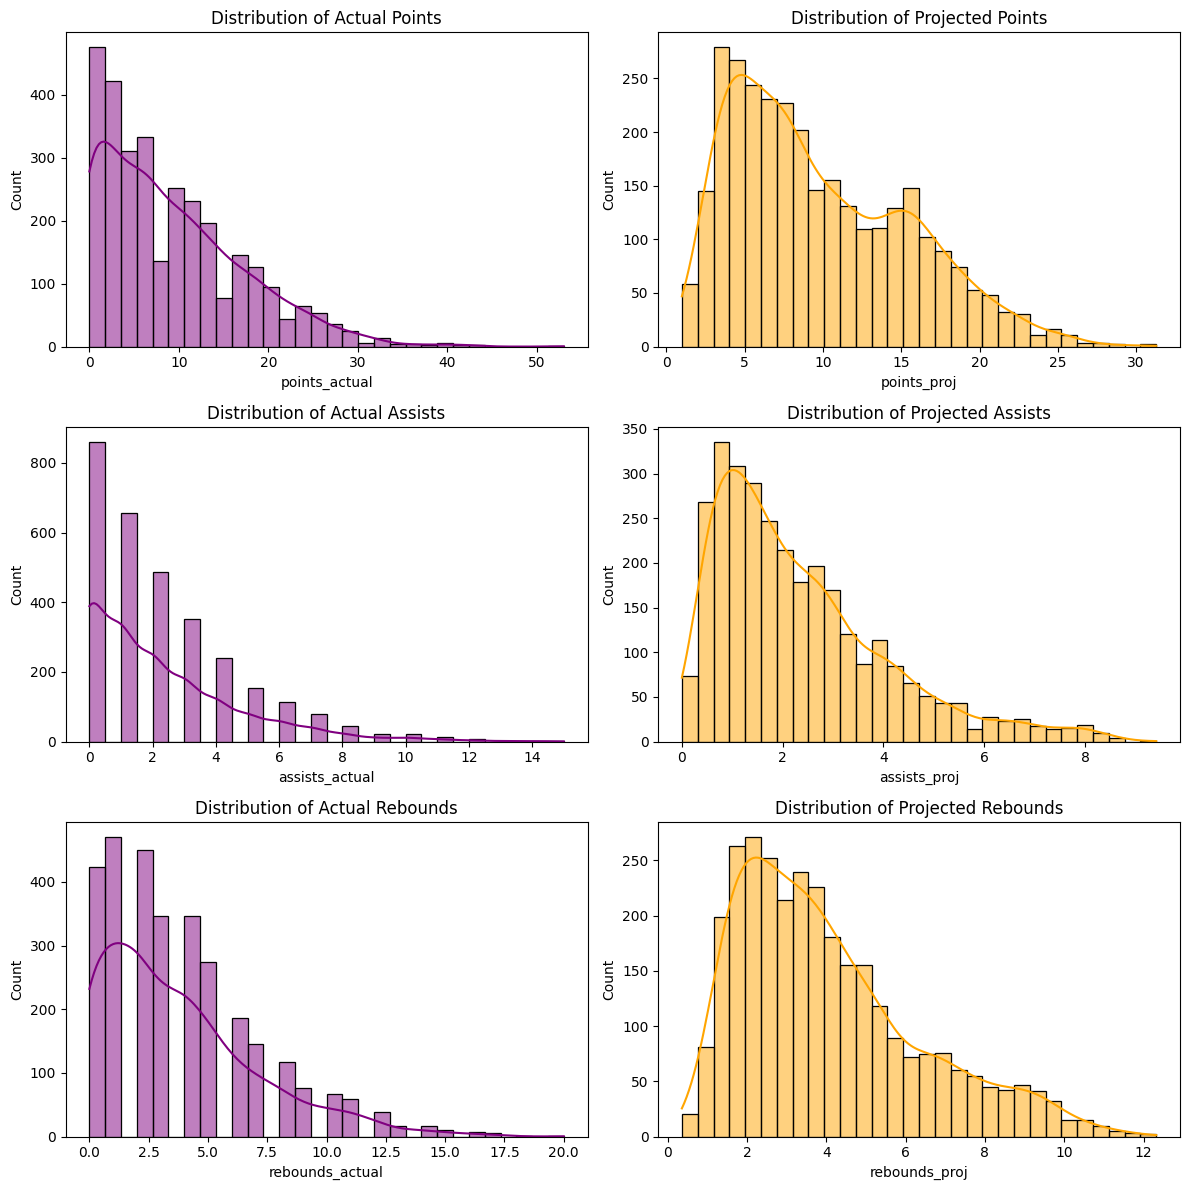

In [16]:
# Define categories
categories = [
    ('points_actual', 'points_proj', 'Points'),
    ('assists_actual', 'assists_proj', 'Assists'),
    ('rebounds_actual', 'rebounds_proj', 'Rebounds')
]

# Create a figure with 3 rows and 2 columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))

for i, (actual, proj, label) in enumerate(categories):
    # Distribution of actual data
    sns.histplot(final_merged_df[actual], bins=30, kde=True, color='purple', edgecolor='black', ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of Actual {label}')
    
    # Distribution of projected data
    sns.histplot(final_merged_df[proj], bins=30, kde=True, color='orange', edgecolor='black', ax=axes[i, 1])
    axes[i, 1].set_title(f'Distribution of Projected {label}')

# Adjust layout
plt.tight_layout()
plt.show()

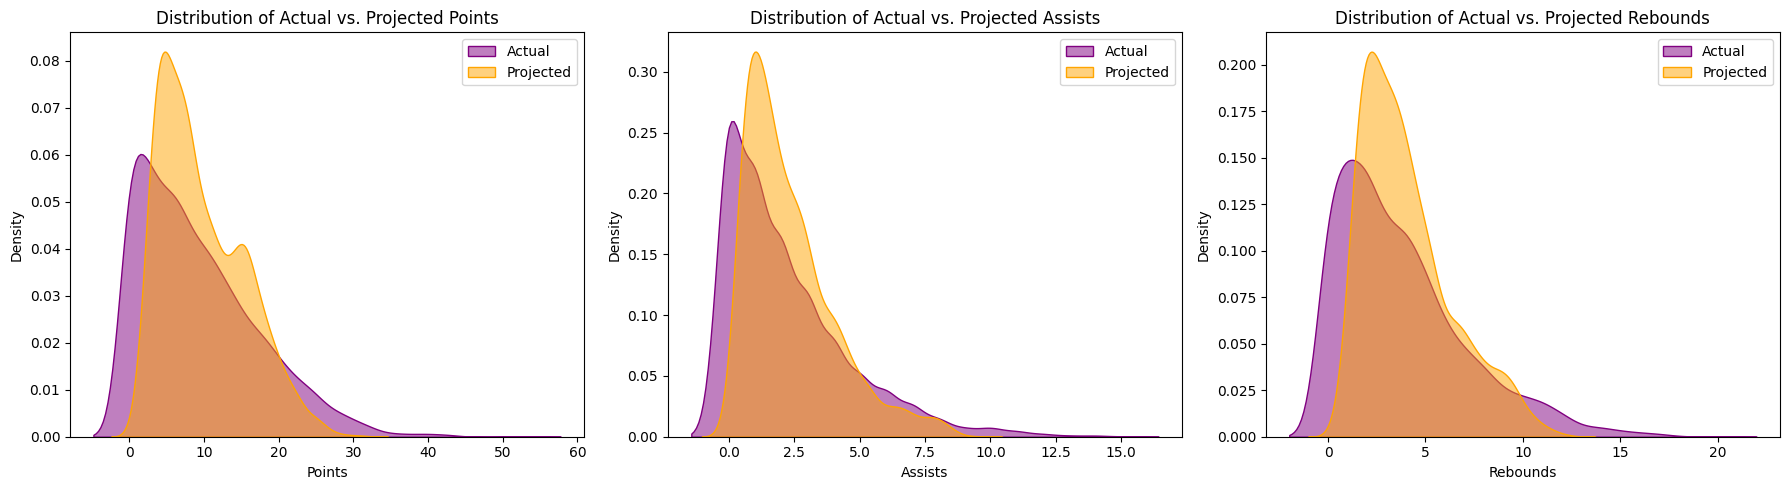

In [17]:
# Plot the distributions of the actual and projected performance together in overlapping histograms
# Create figure with three subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# Loop through each metric and create the plot
for i, (actual, proj, label) in enumerate(categories):

    # Plot Actual vs. Projected distributions
    sns.kdeplot(final_merged_df[actual], label="Actual", color='purple', ax=axes[i], fill=True, alpha=0.5)
    sns.kdeplot(final_merged_df[proj], label="Projected", color='orange', ax=axes[i], fill=True, alpha=0.5)

    # Set title and labels
    axes[i].set_title(f"Distribution of Actual vs. Projected {label}")
    axes[i].set_xlabel(label)
    axes[i].legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()

### __5.1 Run Statistical Tests to Determine the Distribution Similarity of Actual and Projected Data__

In [18]:
# Define a function to perform statistical tests
def test_distribution_similarity(actual, projected, label):
    """
    Performs the Kolmogorov-Smirnov test and Shapiro-Wilk test 
    to check if the actual and projected distributions are the same.
    """

    # Kolmogorov-Smirnov Test (KS Test)
    ks_stat, ks_p_value = stats.ks_2samp(actual, projected)

    # Print results
    print(f"\n==== Statistical Test Results for {label} ====")
    print(f"Kolmogorov-Smirnov Test: D={ks_stat:.4f}, p-value={ks_p_value:.4f}")
    
    # Decision rule for KS test
    if ks_p_value > 0.05:
        print(f"✅ The projected {label} distribution is statistically similar to the actual {label} distribution.")
    else:
        print(f"❌ The projected {label} distribution is statistically different from the actual {label} distribution.")

# Run tests for each category
for actual_col, projected_col, metric_label in categories:
    test_distribution_similarity(
        final_merged_df[actual_col],
        final_merged_df[projected_col],
        metric_label
    )



==== Statistical Test Results for Points ====
Kolmogorov-Smirnov Test: D=0.2279, p-value=0.0000
❌ The projected Points distribution is statistically different from the actual Points distribution.

==== Statistical Test Results for Assists ====
Kolmogorov-Smirnov Test: D=0.2775, p-value=0.0000
❌ The projected Assists distribution is statistically different from the actual Assists distribution.

==== Statistical Test Results for Rebounds ====
Kolmogorov-Smirnov Test: D=0.2690, p-value=0.0000
❌ The projected Rebounds distribution is statistically different from the actual Rebounds distribution.


## __Step 6: Visualize Projection Accuracy__
Generate scatter plots and histograms to analyze the accuracy of point projections.

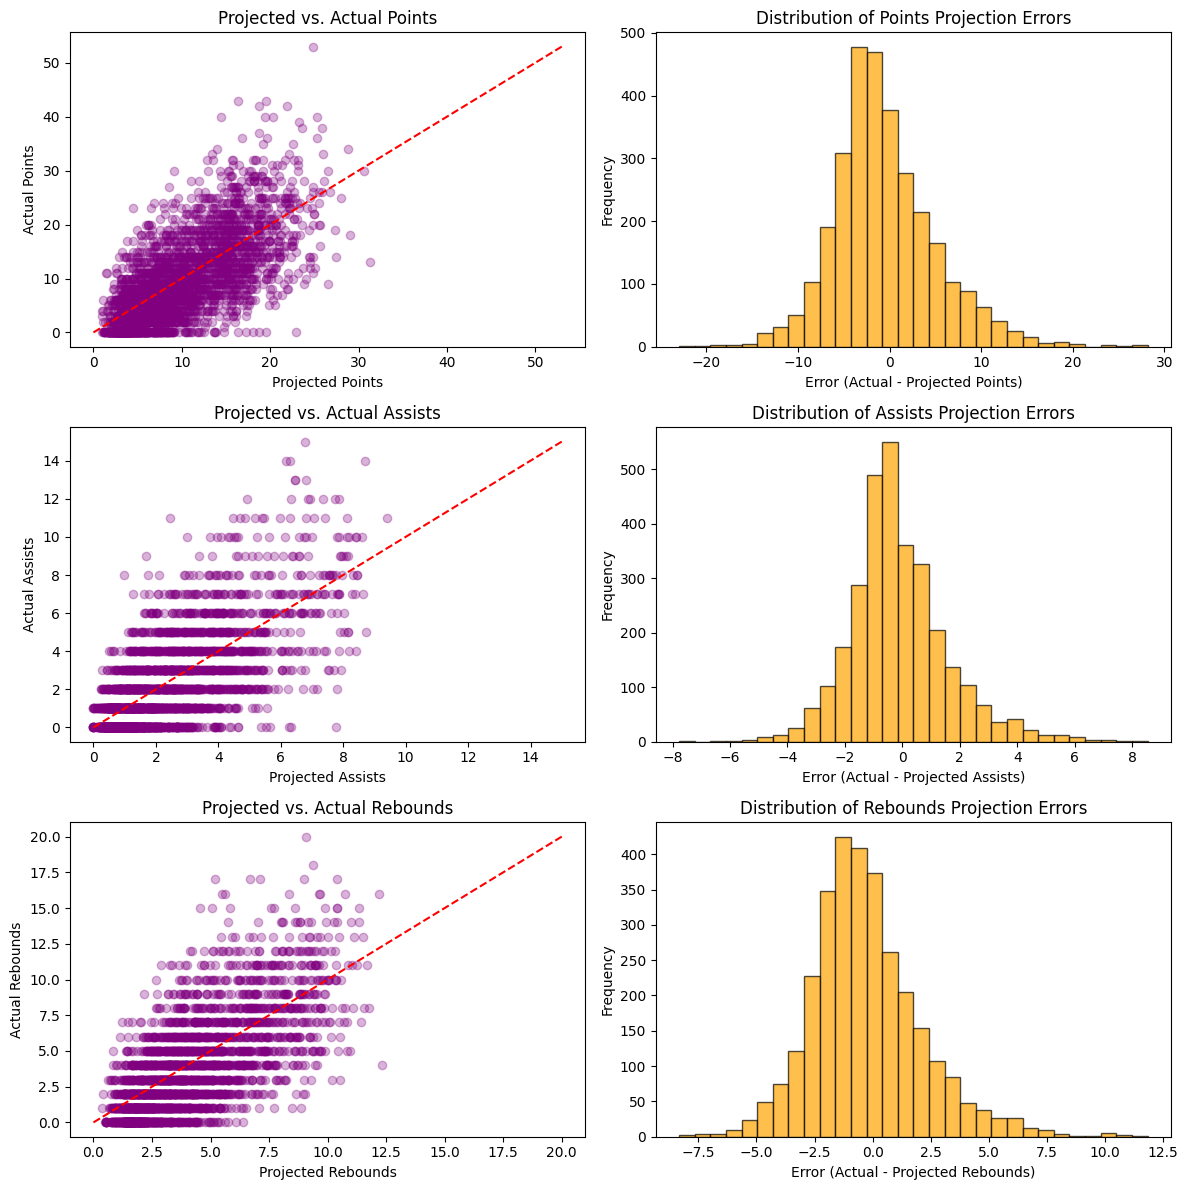

In [19]:
# Define categories
categories_a = [
    ('points_proj', 'points_actual', 'Points Error', 'Points'),
    ('assists_proj', 'assists_actual', 'Assists Error', 'Assists'),
    ('rebounds_proj', 'rebounds_actual', 'Rebounds Error', 'Rebounds')
]

# Create a figure with 3 rows and 2 columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))

for i, (proj, actual, error, label) in enumerate(categories_a):
    # Scatter plot
    ax1 = axes[i, 0]
    ax1.scatter(final_merged_df[proj], final_merged_df[actual], color='purple', alpha=0.3)
    ax1.plot([0, max(final_merged_df[actual])], [0, max(final_merged_df[actual])], 'r--')  # Diagonal reference line
    ax1.set_xlabel(f'Projected {label}')
    ax1.set_ylabel(f'Actual {label}')
    ax1.set_title(f'Projected vs. Actual {label}')
    
    # Histogram of errors
    ax2 = axes[i, 1]
    ax2.hist(final_merged_df[error], bins=30, alpha=0.7, color='orange', edgecolor='black')
    ax2.set_xlabel(f'Error (Actual - Projected {label})')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'Distribution of {label} Projection Errors')

# Adjust layout
plt.tight_layout()
plt.show()

## __Step 7: Run Statistical Tests to Determine the Distrubtions of Projection Errors__

In [20]:
# Define a function to test multiple distributions to determine the best fit for the projection errors
def fit_distributions(data, label):
    """
    Tests multiple distributions to determine the best fit for the given data.
    Uses the Kolmogorov-Smirnov (KS) test and Akaike Information Criterion (AIC).
    """

    # List of candidate distributions (excluding lognorm, gamma, and poisson)
    distributions = ['norm', 't', 'laplace', 'logistic']

    # Remove NaN values
    data = data.dropna()

    results = []
    
    for dist_name in distributions:
        dist = getattr(stats, dist_name)

        # Fit the distribution
        param = dist.fit(data)

        # Perform the KS test
        ks_stat, ks_p_value = stats.kstest(data, dist_name, args=param)

        # Compute log-likelihood
        log_likelihood = np.sum(np.log(dist.pdf(data, *param)))

        # Compute AIC (lower AIC means better fit)
        k = len(param)  # Number of parameters
        aic = 2 * k - 2 * log_likelihood

        results.append((dist_name, ks_stat, ks_p_value, aic))

    # Convert results to a DataFrame and sort by AIC
    results_df = pd.DataFrame(results, columns=['Distribution', 'KS Statistic', 'P-Value', 'AIC'])
    results_df = results_df.sort_values(by=['AIC', 'KS Statistic'])

    print(f"\n==== Best Distribution Fit for {label} ====")
    print(results_df.head(3))  # Show top 3 best fits

# Define Error Categories
categories_b = [
    ('Points Error', 'Points'),
    ('Assists Error', 'Assists'),
    ('Rebounds Error', 'Rebounds')
]

# Run distribution fitting tests for each error category
for error, metric_label in categories_b:
    fit_distributions(final_merged_df[error], metric_label)


==== Best Distribution Fit for Points ====
  Distribution  KS Statistic       P-Value           AIC
3     logistic      0.041478  5.204433e-05  19104.537251
1            t      0.038164  2.624195e-04  19104.711521
2      laplace      0.052016  1.239375e-07  19147.946207

==== Best Distribution Fit for Assists ====
  Distribution  KS Statistic       P-Value           AIC
2      laplace      0.050545  3.125932e-07  11782.069125
1            t      0.034460  1.365278e-03  11782.386896
3     logistic      0.047104  2.451488e-06  11817.963791

==== Best Distribution Fit for Rebounds ====
  Distribution  KS Statistic   P-Value           AIC
1            t      0.029323  0.010180  13851.566722
3     logistic      0.030846  0.005803  13856.145934
2      laplace      0.041461  0.000053  13919.299945


### __7.1 Intepretation of Best-Fitting Distributions for Projection Errors__

<br> 1. Projection errors for points are approximately symmetric but heavy-tailed, making the logistic distribution the best fit. <br> __Implication__: The model sometimes underestimates or overestimates by a large margin. <br> 2. Projection errors for assists are symmetrical but have occasional large deviations, making the Laplace distribution the best fit. <br> __Implication__: The model predicts assists fairly well most of the time, but occasionally makes large errors. <br> 3. Projection errors for rebounds are  are symmetric but have heavier tails than normal. Most rebound errors are small, but some large underestimates and overestimates occur. <br> __Implication__: The model occasionally makes very large rebound errors. Instead of assuming a simple bias (underestimation or overestimation), analyze extreme cases where projections fail.

### __7.2 Recommendations for Model Improvement__

<br> __1. Adjust Prediction Intervals Based on Distributions:__ Instead of using a normal-based confidence interval, use logistic intervals for points, Laplace for assists, and Student’s t for rebounds. <br> __2. Modify Loss Functions in Machine Learning Models:__ If training an ML model, use the appropriate probability distribution for error calculations. Example: Use Laplace loss (L1 loss) for assists since Laplace distribution fits best. Consider Huber loss for rebounds<br> __3. Handle Outliers More Carefully:__ Since points, assists, and rebounds all have heavy-tailed distributions, robust regression techniques should be applied across all three metrics. Consider Bayesian inference for rebounds and quantile regression for assists to better model large deviations.

## __Step 8: Choose the Performance Metrics Based on Statistical Test Results__

__Based on the distribution analysis of projection errors, I will use MAE (Mean Absolute Error) as the baseline metric and use MDAPE (Median Absolute Percentage Error) and WAPE (Weighted Absolute Percentage Error) as secondary metrics for evaluating projection performance.__ Because the actual data such as points are heavily skewed and have many small values, MAPE is not a good metric for this case because it is too sensitive to small values. 

__1. Justification for Using MAE as the Baseline Metric__  <br> __- Works well with heavy-tailed distributions (Logistic, Laplace, Student's t-distribution)__ <br> Since points errors follow a logistic distribution, assists errors follow a Laplace distribution, and rebounds errors follow a Student's t-distribution, MAE remains a stable and interpretable measure even in the presence of outliers and heavy tails.  <br> __- Does not amplify extreme errors__ <br> o	Unlike Root Mean Squared Error (RMSE), which gives more weight to larger errors, MAE treats all errors equally, making it a more appropriate metric for heavy-tailed distributions where extreme values exist. <br> __- Easy to interpret__ <br> A simple measure of the average absolute deviation from the actual value, making it intuitive for both technical and business stakeholders.   <br> __-  Conclusion:__ <br> Given that projection errors do not follow a normal distribution and exhibit heavy tails, MAE is a robust baseline metric that does not get affected by outliers as severely as MSE or RMSE.  

__2. Justification for Using MDAPE and WAPE as Secondary Metrics__  <br> __- MDAPE (Mean Directional Accuracy Percentage Error) robust to heavy-tailed errors__ <br> MDAPE is robust to heavy-tailed distributions, like the t-distribution for rebounds and logistic/Laplace for points and assists, because it uses the median instead of the mean, making it less sensitive to extreme errors. It also evaluates whether the model tends to overestimate or underestimate projections across different players. <br> __-  WAPE (Weighted Absolute Percentage Error) balances impact across different scales__ <br> Since players have varying stat totals (e.g., some average 20+ points, others 5+ assists, etc.), WAPE prevents small-value players from dominating error percentages. Useful in cases where errors need to be compared across players with different total values.  <br> __-  Conclusion:__ <br> Both MDAPE and WAPE provide additional insights into projection bias and accuracy across different value ranges, making them useful secondary metrics.

## __Step 9: Calculate Projection Accuracy Metrics__
__Compute MAE, MDAPE, and WAPE for Points, Assists, and Rebounds.__

In [21]:
# Define a function to calculate Median Absolute Percentage Error(MDAPE)
def calculate_mdape(actual, predicted):
    # Filter out zero actual values to avoid division by zero
    percentage_errors = abs(actual - predicted) / actual
    percentage_errors = percentage_errors[actual > 0]  # Exclude zero actuals
    mdape = np.median(percentage_errors) * 100
    return mdape

# Define a function to calculate Weighted Absolute Percentage Error(WAPE)
def calculate_wape(actual, predicted):
    # Ensure there are no zero values in actual to prevent division errors
    total_actual = actual.sum()
    total_absolute_error = (abs(actual - predicted)).sum()
    wape = (total_absolute_error / total_actual) * 100
    return wape

In [22]:
# Compute MAE, MAPE, MDAPE and WAPE for Points
mae_points = mean_absolute_error(final_merged_df['points_actual'], final_merged_df['points_proj'])
mdape_points = calculate_mdape(final_merged_df['points_actual'], final_merged_df['points_proj'])
wape_points = calculate_wape(final_merged_df['points_actual'], final_merged_df['points_proj'])

# Compute Metrics for Assists
mae_assists = mean_absolute_error(final_merged_df['assists_actual'], final_merged_df['assists_proj'])
mdape_assists = calculate_mdape(final_merged_df['assists_actual'], final_merged_df['assists_proj'])
wape_assists = calculate_wape(final_merged_df['assists_actual'], final_merged_df['assists_proj'])

# Compute Metrics for Rebounds
mae_rebounds = mean_absolute_error(final_merged_df['rebounds_actual'], final_merged_df['rebounds_proj'])
mdape_rebounds = calculate_mdape(final_merged_df['rebounds_actual'], final_merged_df['rebounds_proj'])
wape_rebounds = calculate_wape(final_merged_df['rebounds_actual'], final_merged_df['rebounds_proj'])

# Store results in a DataFrame
metrics_overall_df = pd.DataFrame({
    'Metrics': ['MAE', 'MDAPE', 'WAPE'],
    'Points': [mae_points, mdape_points, wape_points],
    'Assists': [mae_assists, mdape_assists, wape_assists],
    'Rebounds': [mae_rebounds, mdape_rebounds, wape_rebounds]
})

# Formatting function for readability (number and percentage formatting)
def format_values(row):
    if row['Metrics'] == 'MAE':
        return row.iloc[1:].apply(lambda x: f"{x:.1f}")  # MAE: 1 decimal
    else:
        return row.iloc[1:].apply(lambda x: f"{x:.1f}%")  #  MDAPE, WAPE: 1 decimal + %

# Apply formatting
metrics_overall_df.iloc[:, 1:] = metrics_overall_df.apply(format_values, axis=1)

# Define a function to compute and format metrics by group (Fixes TypeError)
def compute_grouped_metrics(df, group_by_column):
    grouped_df = (
        df.drop(columns=[group_by_column])  # Drop the group_by_column before applying functions
        .groupby(df[group_by_column])       # Perform groupby without modifying the column
        .apply(lambda x: pd.Series({
            'MAE_Points': mean_absolute_error(x['points_actual'], x['points_proj']),
            'MDAPE_Points': calculate_mdape(x['points_actual'], x['points_proj']),
            'WAPE_Points': calculate_wape(x['points_actual'], x['points_proj']),
            'MAE_Assists': mean_absolute_error(x['assists_actual'], x['assists_proj']),
            'MDAPE_Assists': calculate_mdape(x['assists_actual'], x['assists_proj']),
            'WAPE_Assists': calculate_wape(x['assists_actual'], x['assists_proj']),
            'MAE_Rebounds': mean_absolute_error(x['rebounds_actual'], x['rebounds_proj']),
            'MDAPE_Rebounds': calculate_mdape(x['rebounds_actual'], x['rebounds_proj']),
            'WAPE_Rebounds': calculate_wape(x['rebounds_actual'], x['rebounds_proj']),
        }))
        .reset_index()
    )

    # Convert MAE values to 1 decimal place
    mae_columns = ['MAE_Points', 'MAE_Assists', 'MAE_Rebounds']
    for col in mae_columns:
        grouped_df[col] = grouped_df[col].apply(lambda x: f"{x:.1f}")  # Convert to 1 decimal place
    
    # Convert percentage-based columns to string with "%"
    percentage_columns = [
        'MDAPE_Points', 'WAPE_Points', 
        'MDAPE_Assists', 'WAPE_Assists', 
        'MDAPE_Rebounds', 'WAPE_Rebounds'
    ]
    for col in percentage_columns:
        grouped_df[col] = grouped_df[col].apply(lambda x: f"{x:.1f}%")  # Add percentage formatting
    
    return grouped_df

# Compute metrics grouped by different categories
metrics_by_event_type = compute_grouped_metrics(final_merged_df, 'event_type')
metrics_by_starter = compute_grouped_metrics(final_merged_df, 'starter_actual')

# Display the results in the terminal
print("\n===== Overall Projection Accuracy =====")
print(metrics_overall_df.to_string(index=False))

print("\n===== Projection Accuracy by Event Type =====")
print(metrics_by_event_type.to_string(index=False))

print("\n===== Projection Accuracy by Starter Status =====")
print(metrics_by_starter.to_string(index=False))


===== Overall Projection Accuracy =====
Metrics Points Assists Rebounds
    MAE    4.4     1.3      1.8
  MDAPE  36.6%   40.7%    37.3%
   WAPE  47.4%   58.8%    48.9%

===== Projection Accuracy by Event Type =====
event_type MAE_Points MDAPE_Points WAPE_Points MAE_Assists MDAPE_Assists WAPE_Assists MAE_Rebounds MDAPE_Rebounds WAPE_Rebounds
       pst        4.8        38.1%       47.4%         1.3         35.8%        54.9%          2.0          37.5%         43.8%
       reg        4.3        36.5%       47.5%         1.3         41.2%        59.3%          1.8          37.2%         49.7%

===== Projection Accuracy by Starter Status =====
 starter_actual MAE_Points MDAPE_Points WAPE_Points MAE_Assists MDAPE_Assists WAPE_Assists MAE_Rebounds MDAPE_Rebounds WAPE_Rebounds
              0        3.4        46.1%       80.7%         1.0         43.5%       100.7%          1.5          44.2%         75.0%
              1        5.1        32.4%       38.9%         1.6         38.7%      

### __Step 9.1: Analysis of Projection Accuracy Results__

__1.  Impact of Event Type (Regular vs. Playoffs)__  <br> __- Projection accuracy does not significantly differ between regular season (reg) and playoffs (psg)__ <br> - MAE values remain relatively stable across both event types.  <br> - MDAPE and WAPE percentages show slight variations but no strong trend indicating a substantial difference. <br> - This suggests that the model performs consistently regardless of the season type, meaning external postseason factors (such as increased competitiveness or playoff pressure) do not meaningfully impact projection accuracy.  <br> __-  Conclusion:__ <br> __Event type (regular vs. postseason) has minimal impact on projection accuracy.__ 

__1.   Impact of Starter Status (Bench Players vs. Starters)__  <br> __- MAE is lower for bench players__ (actual_starter = 0) than for starters (actual_starter = 1), indicating that the absolute difference between actual and projected values is slightly reduced for non-starters. <br> - However, __relative error percentages (MDAPE & WAPE) significantly increase for bench players:__  <br> - __MDAPE increased by ~42% for points, ~12% for assists, and ~32% for rebounds.__ <br> - __WAPE more than doubled across all metrics (e.g., increasing from 38.9% to 80.7% for points).__ <br> - This indicates that while __bench players have lower raw statistical outputs, the projection model struggles to accurately capture their variability.__  <br> __-  Conclusion:__ <br> __Starter status has a significant impact on projection accuracy.__  <br> - __The projection model performs much better for starters__ than for bench players. <br> - __Bench players’ performance is harder to predict__, possibly due to inconsistent minutes, unpredictable playing time, or varying game roles.

## __Step 10: Export Cleaned Data for Power BI__
Save the cleaned dataset as a CSV file for Power BI visualization.

In [23]:

# Define output path
output_path = r"../data/processed/cleaned_WNBA_projections.csv"

# Save cleaned DataFrame to CSV
final_merged_df.to_csv(output_path, index=False)

print(f"Processed data saved to {output_path}")


Processed data saved to cleaned_WNBA_projections.csv
